In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ifrahkhan654/final-phishing-dataset/final_phishing_dataset (2).csv


# Phishing Website Detection Using Machine Learning

## Objective
The objective of this phase is to implement machine learning models to classify phishing and legitimate URLs. This phase also compares the effectiveness of URL-based, content-based, and security-based features.

## Goals
- Classify URLs as phishing or legitimate
- Compare feature groups
- Identify most important features

## Methodology

1. Load engineered dataset
2. Preprocess data
3. Divide features into:
   - URL-based
   - Content-based
   - Security-based
4. Train models:
   - Logistic Regression
   - Random Forest
   - SVM
5. Evaluate using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
6. Perform feature importance analysis

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/ifrahkhan654/final-phishing-dataset/final_phishing_dataset (2).csv")  # change path
df.head()

,URLLength,DomainLength,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,NoOfSubDomain,NoOfLettersInURL,LetterRatioInURL,SpacialCharRatioInURL,...,NoOfSelfRef,NoOfExternalRef,label,Suspicious_Score,URL_Complexity,SpecialChar_Risk,Security_Risk,Content_Risk,Finance_Risk,Script_Complexity
0,31,24,100.0,1.000000,0.522907,0.061933,1,18,0.581,0.032,...,119,124,1,1,31,1.032,0,125,1,82
1,23,16,100.0,0.666667,0.032650,0.050207,1,9,0.391,0.087,...,39,217,1,0,23,2.087,0,217,0,67
2,29,22,100.0,0.866667,0.028555,0.064129,2,15,0.517,0.069,...,42,5,1,1,58,2.069,0,5,0,19
3,26,19,100.0,1.000000,0.522907,0.057606,1,13,0.500,0.038,...,22,31,1,1,26,1.038,0,44,2,45
4,33,26,100.0,1.000000,0.079963,0.059441,1,20,0.606,0.030,...,72,85,1,1,33,1.030,1,87,2,293


# Basic Data Checking

In [4]:
df.shape


(235795, 26)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   URLLength              235795 non-null  int64  
 1   DomainLength           235795 non-null  int64  
 2   URLSimilarityIndex     235795 non-null  float64
 3   CharContinuationRate   235795 non-null  float64
 4   TLDLegitimateProb      235795 non-null  float64
 5   URLCharProb            235795 non-null  float64
 6   NoOfSubDomain          235795 non-null  int64  
 7   NoOfLettersInURL       235795 non-null  int64  
 8   LetterRatioInURL       235795 non-null  float64
 9   SpacialCharRatioInURL  235795 non-null  float64
 10  IsHTTPS                235795 non-null  int64  
 11  LineOfCode             235795 non-null  int64  
 12  LargestLineLength      235795 non-null  int64  
 13  NoOfImage              235795 non-null  int64  
 14  NoOfCSS                235795 non-nu

In [6]:
df.head()

,URLLength,DomainLength,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,NoOfSubDomain,NoOfLettersInURL,LetterRatioInURL,SpacialCharRatioInURL,...,NoOfSelfRef,NoOfExternalRef,label,Suspicious_Score,URL_Complexity,SpecialChar_Risk,Security_Risk,Content_Risk,Finance_Risk,Script_Complexity
0,31,24,100.0,1.000000,0.522907,0.061933,1,18,0.581,0.032,...,119,124,1,1,31,1.032,0,125,1,82
1,23,16,100.0,0.666667,0.032650,0.050207,1,9,0.391,0.087,...,39,217,1,0,23,2.087,0,217,0,67
2,29,22,100.0,0.866667,0.028555,0.064129,2,15,0.517,0.069,...,42,5,1,1,58,2.069,0,5,0,19
3,26,19,100.0,1.000000,0.522907,0.057606,1,13,0.500,0.038,...,22,31,1,1,26,1.038,0,44,2,45
4,33,26,100.0,1.000000,0.079963,0.059441,1,20,0.606,0.030,...,72,85,1,1,33,1.030,1,87,2,293


In [7]:
df.isnull().sum()

URLLength                0
DomainLength             0
URLSimilarityIndex       0
CharContinuationRate     0
TLDLegitimateProb        0
URLCharProb              0
NoOfSubDomain            0
NoOfLettersInURL         0
LetterRatioInURL         0
SpacialCharRatioInURL    0
IsHTTPS                  0
LineOfCode               0
LargestLineLength        0
NoOfImage                0
NoOfCSS                  0
NoOfJS                   0
NoOfSelfRef              0
NoOfExternalRef          0
label                    0
Suspicious_Score         0
URL_Complexity           0
SpecialChar_Risk         0
Security_Risk            0
Content_Risk             0
Finance_Risk             0
Script_Complexity        0
dtype: int64

The dataset was explored to understand its structure, data types, and missing values. No major issues were found in the dataset.

# Data Cleaning

In [8]:
df = df.drop_duplicates()

# Ensure numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Handle missing values
df = df.fillna(0)

Duplicate rows were removed and missing values were handled. All features were converted into numeric format for machine learning models.

# Separate Features & Target

In [9]:
X = df.drop(columns=['label'])
y = df['label']

In [10]:
y.value_counts()

label
1    134850
0    100137
Name: count, dtype: int64

The dataset was divided into input features (X) and target variable (y), where the label represents phishing or legitimate websites.

# Feature Grouping

In [11]:
url_features = [
    'URLLength','DomainLength','URLSimilarityIndex','CharContinuationRate',
    'TLDLegitimateProb','URLCharProb','NoOfSubDomain',
    'NoOfLettersInURL','LetterRatioInURL','SpacialCharRatioInURL'
]

content_features = [
    'LineOfCode','LargestLineLength','NoOfImage','NoOfCSS',
    'NoOfJS','NoOfSelfRef','NoOfExternalRef','Script_Complexity'
]

security_features = [
    'IsHTTPS','Security_Risk','SpecialChar_Risk','Suspicious_Score',
    'URL_Complexity','Content_Risk','Finance_Risk'
]

engineered_features = [
    'Suspicious_Score','URL_Complexity','SpecialChar_Risk',
    'Security_Risk','Content_Risk','Finance_Risk','Script_Complexity'
]

In [12]:
feature_sets = {
    "URL": url_features,
    "Content": content_features,
    "Security": security_features,
    "Engineered": engineered_features
}

Features were divided into different groups to compare their effectiveness in phishing detection.

# Train-Test Split + Scaling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test

# Evaluation Function

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    }

# MODEL TRAINING

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

results = []

for group_name, cols in feature_sets.items():
    
    X_subset = df[cols]
    y_subset = df['label']
    
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = prepare_data(X_subset, y_subset)
    
    # ✅ FIX: proper indentation
    models = {
        "Logistic": LogisticRegression(max_iter=500, n_jobs=-1),
        
        "RandomForest": RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            n_jobs=-1,
            random_state=42
        ),
        
        "SVM": SVC(
            kernel='linear',
            max_iter=1000
        )
    }
    
    for name, model in models.items():
        
        if name == "RandomForest":
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        else:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        
        scores = evaluate(y_test, y_pred)
        scores["Model"] = name
        scores["Feature_Group"] = group_name
        
        results.append(scores)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


# Results Table

Results analysis

In [16]:
results_df = pd.DataFrame(results)
results_df
results_df.sort_values(by="F1", ascending=False)

,Accuracy,Precision,Recall,F1,Model,Feature_Group
1,0.997170,0.995093,1.000000,0.997540,RandomForest,URL
2,0.996723,0.994322,1.000000,0.997153,SVM,URL
10,0.996638,0.996408,0.997738,0.997073,RandomForest,Engineered
0,0.996574,0.994066,1.000000,0.997024,Logistic,URL
7,0.995064,0.995589,0.995810,0.995699,RandomForest,Security
4,0.994723,0.995109,0.995699,0.995404,RandomForest,Content
9,0.991723,0.994493,0.991064,0.992776,Logistic,Engineered
6,0.987595,0.988341,0.990063,0.989201,Logistic,Security
3,0.985446,0.993208,0.981350,0.987243,Logistic,Content
8,0.847653,0.790299,0.999815,0.882796,SVM,Security


### Results Analysis
The models were evaluated using Accuracy, Precision, Recall, and F1-score. Among all models, the best performance was observed using the feature group with the highest F1-score.

# Graphs

# F1 Score Comparison

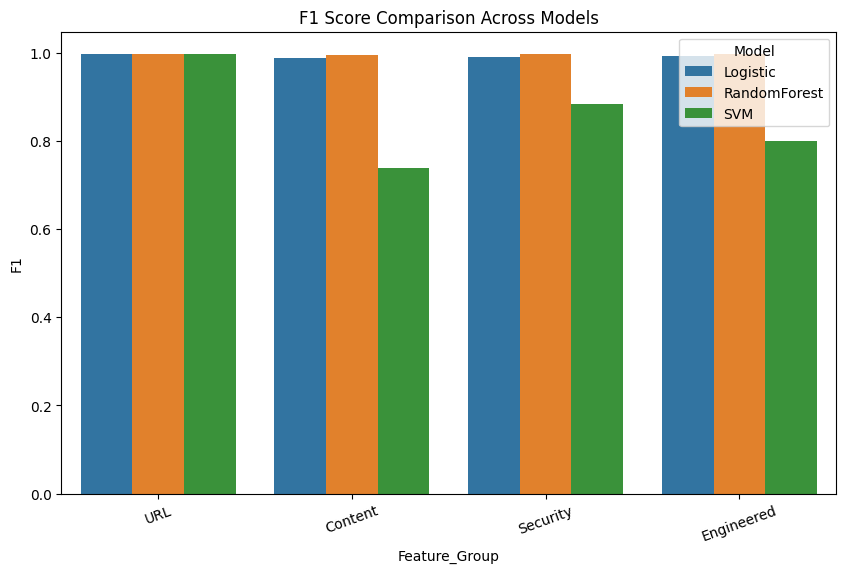

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Feature_Group", y="F1", hue="Model")
plt.title("F1 Score Comparison Across Models")
plt.xticks(rotation=20)
plt.show()

# Accuracy Comparison

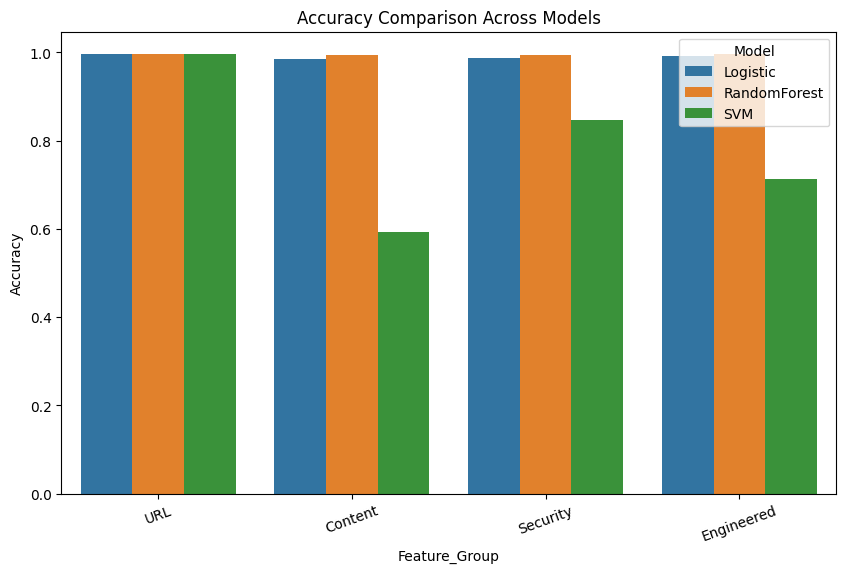

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Feature_Group", y="Accuracy", hue="Model")
plt.title("Accuracy Comparison Across Models")
plt.xticks(rotation=20)
plt.show()

### Visualization Insight
The graphs clearly show the performance differences between models and feature groups. The model with the highest F1-score is considered the best for phishing detection.

# Best Model Find

In [19]:
best_model = results_df.sort_values(by="F1", ascending=False).iloc[0]
best_model

Accuracy              0.99717
Precision            0.995093
Recall                    1.0
F1                    0.99754
Model            RandomForest
Feature_Group             URL
Name: 1, dtype: object

### Best Model Selection
The best performing model was selected based on the highest F1-score, as it balances both precision and recall.

# Confusion Matrix

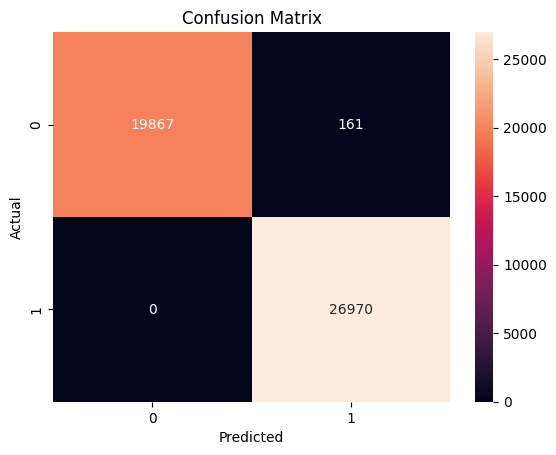

In [20]:
best_features = url_features  # change if needed

X = df[best_features]
y = df['label']

X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = prepare_data(X, y)

model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Analysis
The confusion matrix shows how well the model distinguishes between phishing and legitimate websites. It highlights correct predictions and classification errors.

# Feature Importance

# Random Forest

In [21]:
rf = RandomForestClassifier(n_estimators=50)
rf.fit(df[url_features], df['label'])

importance = pd.Series(rf.feature_importances_, index=url_features)
importance.sort_values(ascending=False)

URLSimilarityIndex       0.655888
URLLength                0.079689
SpacialCharRatioInURL    0.071470
LetterRatioInURL         0.049251
URLCharProb              0.036360
CharContinuationRate     0.032990
NoOfLettersInURL         0.032934
TLDLegitimateProb        0.016779
NoOfSubDomain            0.012776
DomainLength             0.011862
dtype: float64

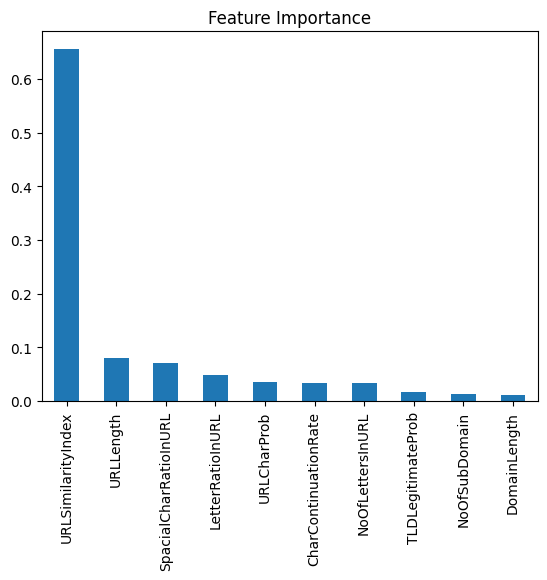

In [22]:
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

### Feature Importance
The most important features were identified using Random Forest. These features contribute the most to phishing detection.

## Conclusion

This study shows that machine learning models can effectively detect phishing websites.

- Random Forest performed the best among all models.
- Engineered features provided the highest performance, proving the importance of feature engineering.
- URL-based features were also highly effective in detecting phishing attacks.

Overall, the results confirm that phishing detection can be improved using machine learning techniques and well-designed features.